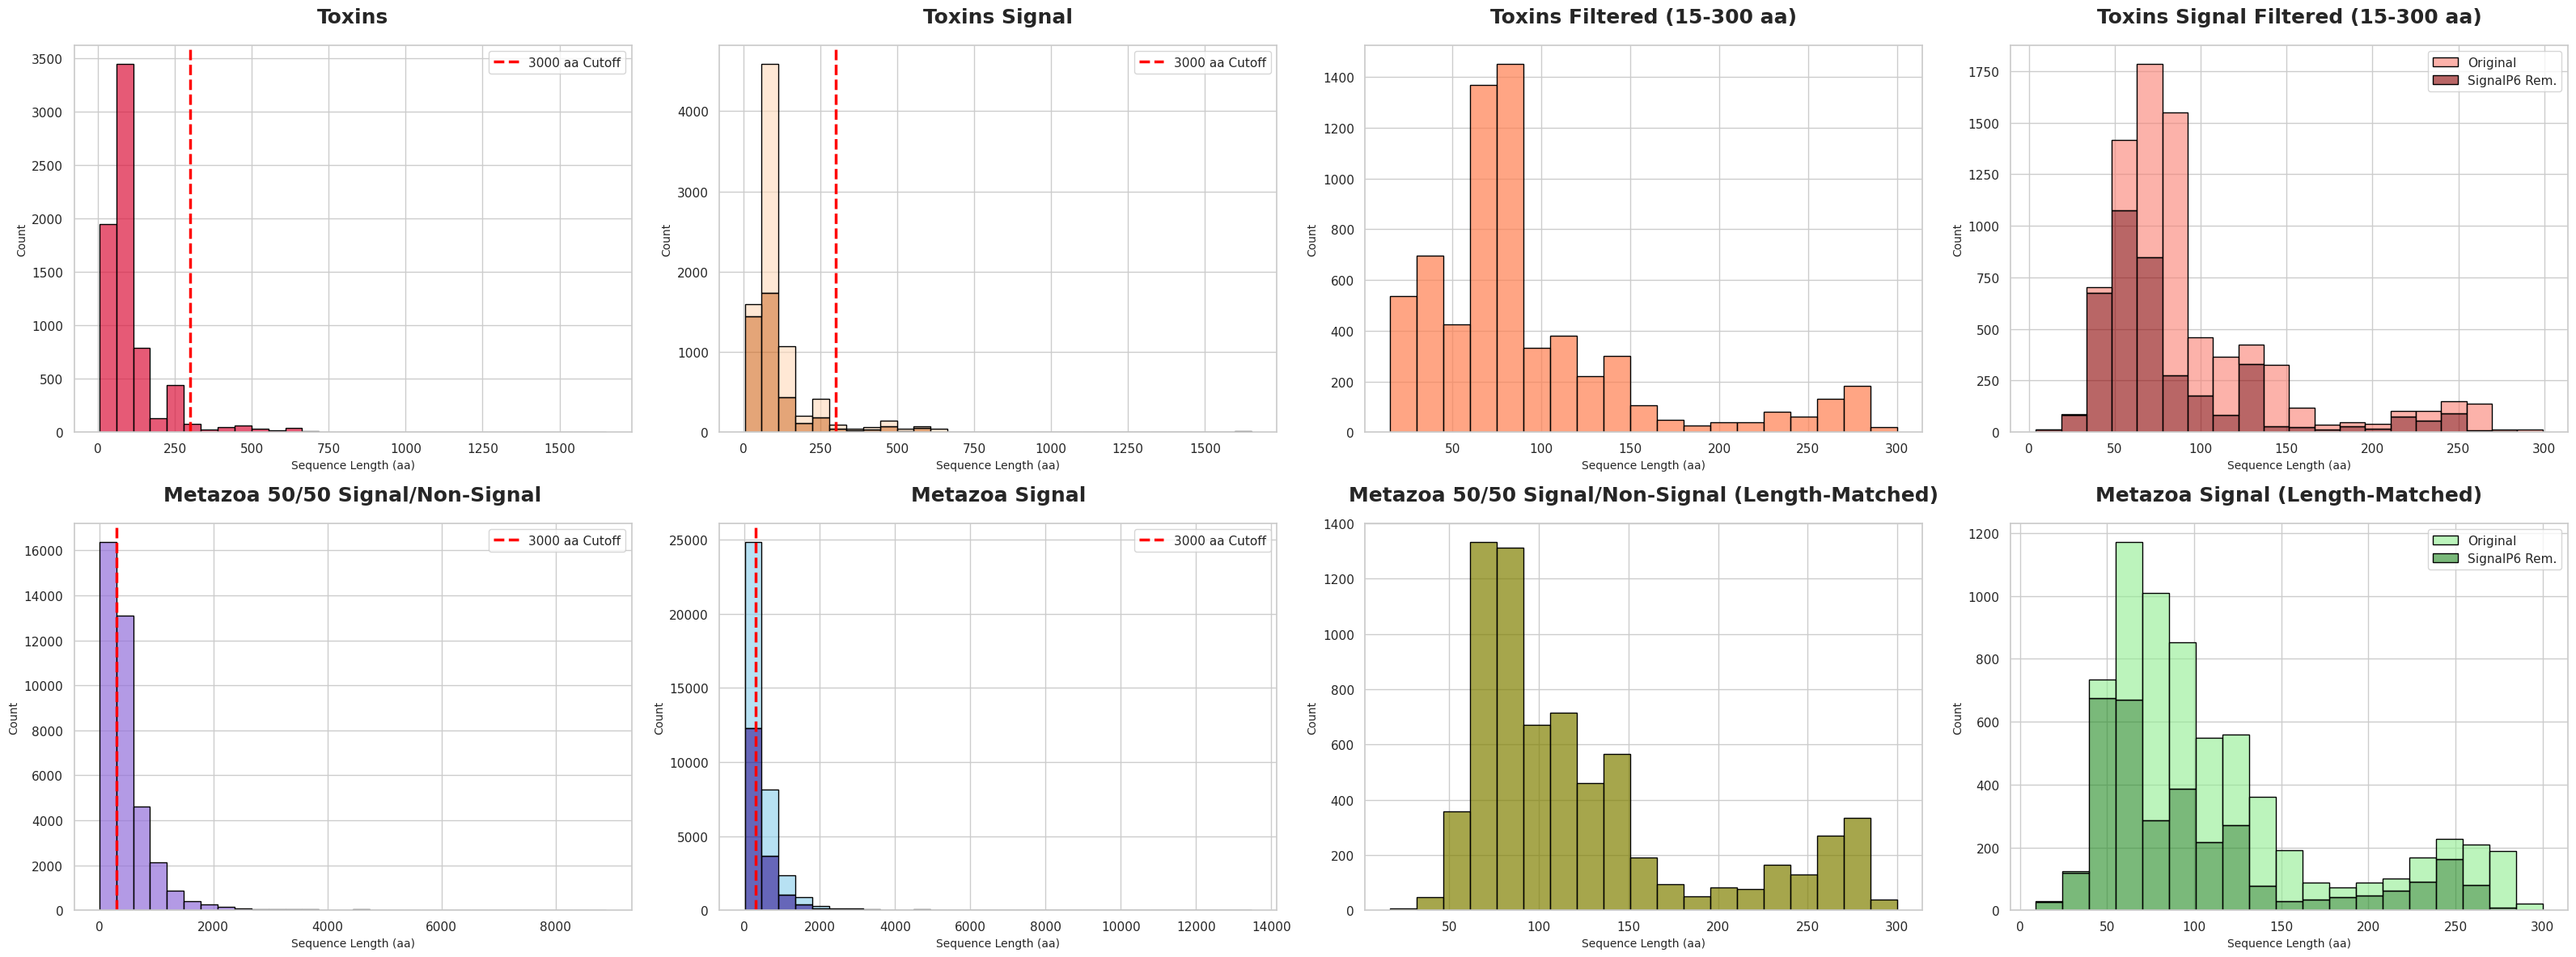

In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. Helper Function for FASTA Processing ---
def get_fasta_records(fasta_path):
    """Parses a FASTA file and returns a dictionary of {protein_id: sequence_length}."""
    if not os.path.exists(fasta_path):
        print(f"Warning: File not found at {fasta_path}. Skipping.")
        return {}
    records = {}
    current_id = None
    current_seq = []
    with open(fasta_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_id is not None:
                    records[current_id] = len("".join(current_seq))
                current_id = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
        if current_id is not None:
            records[current_id] = len("".join(current_seq))
    return records

# --- 2. Load & Process Row 1 Datasets (TSV/CSV) ---
df_toxins = pd.read_csv("datasets/toxins.tsv", sep="\t")
df_signal = pd.read_csv("datasets/metazoa_nontoxin_signalpeptide5050.tsv", sep="\t")
df_nonsignal = pd.read_csv("datasets/metazoa_nontoxin_signalpeptide5050_lengthmatched.tsv", sep="\t")

lengths_toxins_full = df_toxins["Length"].dropna()
lengths_toxins_filtered = lengths_toxins_full[(lengths_toxins_full >= 15) & (lengths_toxins_full <= 300)]
lengths_signal = df_signal["Length"].dropna()
lengths_nonsignal = df_nonsignal["Length"].dropna()

# --- 3. Load & Process Row 2 Datasets (FASTA Pairs) ---
dict_sig_full = get_fasta_records("datasets/metazoa_nontoxin_signalpeptide.fasta")
dict_sig_rem = get_fasta_records("datasets/metazoa_nontoxin_signalpeptide_signalp6_removed.fasta")
len_sig_full = list(dict_sig_full.values())
len_sig_rem = list(dict_sig_rem.values())

dict_matched_full = get_fasta_records("datasets/metazoa_nontoxin_signalpeptide_lengthmatched.fasta")
dict_matched_rem = get_fasta_records("datasets/metazoa_nontoxin_signalpeptide_lengthmatched_signalp6_removed.fasta")
len_matched_full = list(dict_matched_full.values())
len_matched_rem = list(dict_matched_rem.values())

dict_tox_full = get_fasta_records("datasets/toxins_signalpeptide.fasta")
dict_tox_rem = get_fasta_records("datasets/toxins_signalpeptide_signalp6_removed.fasta")
len_tox_full_unfiltered = list(dict_tox_full.values())
len_tox_rem_unfiltered = list(dict_tox_rem.values())

filtered_tox_full = {pid: length for pid, length in dict_tox_full.items() if 15 <= length <= 300}
len_tox_full_filtered = list(filtered_tox_full.values())
valid_toxin_ids = set(filtered_tox_full.keys())
len_tox_rem_filtered = [length for pid, length in dict_tox_rem.items() if pid in valid_toxin_ids]

# --- 4. Plotting Setup (2x4 Grid Layout) ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 4, figsize=(32, 12))

# Title configuration constant to avoid code repetition
TITLE_CONFIG = {"fontsize": 18, "fontweight": "bold", "pad": 20}

# ==========================================
# COL 0 & 1: UNFILTERED (bins=30) with 3000 aa cutoff line
# ==========================================

# [0, 0] Unfiltered: General Toxins Full (TSV)
sns.histplot(x=lengths_toxins_full, kde=False, color="crimson", bins=30, ax=axes[0, 0], edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Toxins", **TITLE_CONFIG)
axes[0, 0].axvline(x=300, color="red", linestyle="--", linewidth=2.5, label="3000 aa Cutoff")
axes[0, 0].legend(fontsize=11)

# [0, 1] Unfiltered: FASTA Toxins Signal (Full Unfiltered)
sns.histplot(data={"Original": len_tox_full_unfiltered, "SignalP6 Rem.": len_tox_rem_unfiltered},
             multiple="stack", bins=30, kde=False, palette={"Original": "peachpuff", "SignalP6 Rem.": "chocolate"},
             edgecolor="black", alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title("Toxins Signal", **TITLE_CONFIG)
axes[0, 1].axvline(x=300, color="red", linestyle="--", linewidth=2.5, label="3000 aa Cutoff")
axes[0, 1].legend(fontsize=11)

# [1, 0] Unfiltered: Metazoa 50/50 Signal (TSV)
sns.histplot(x=lengths_signal, kde=False, color="mediumpurple", bins=30, ax=axes[1, 0], edgecolor="black", alpha=0.7)
axes[1, 0].set_title("Metazoa 50/50 Signal/Non-Signal", **TITLE_CONFIG)
axes[1, 0].axvline(x=300, color="red", linestyle="--", linewidth=2.5, label="3000 aa Cutoff")
axes[1, 0].legend(fontsize=11)

# [1, 1] Unfiltered: FASTA Metazoa Signal (All Lengths)
sns.histplot(data={"Original": len_sig_full, "SignalP6 Rem.": len_sig_rem},
             multiple="stack", bins=30, kde=False, palette={"Original": "skyblue", "SignalP6 Rem.": "darkblue"},
             edgecolor="black", alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title("Metazoa Signal", **TITLE_CONFIG)
axes[1, 1].axvline(x=300, color="red", linestyle="--", linewidth=2.5, label="3000 aa Cutoff")
axes[1, 1].legend(fontsize=11)

# ==========================================
# COL 2 & 3: FILTERED/MATCHED (binwidth=15)
# ==========================================

# [0, 2] Filtered: General Toxins Filtered (TSV)
sns.histplot(x=lengths_toxins_filtered, kde=False, color="coral", binwidth=15, ax=axes[0, 2], edgecolor="black", alpha=0.7)
axes[0, 2].set_title("Toxins Filtered (15-300 aa)", **TITLE_CONFIG)

# [0, 3] Filtered: FASTA Toxins Signal (Filtered 15-300 aa)
sns.histplot(data={"Original": len_tox_full_filtered, "SignalP6 Rem.": len_tox_rem_filtered},
             multiple="stack", binwidth=15, kde=False, palette={"Original": "salmon", "SignalP6 Rem.": "darkred"},
             edgecolor="black", alpha=0.6, ax=axes[0, 3])
axes[0, 3].set_title("Toxins Signal Filtered (15-300 aa)", **TITLE_CONFIG)

# [1, 2] Length-Matched: Metazoa 50/50 Non-Signal (TSV)
sns.histplot(x=lengths_nonsignal, kde=False, color="olive", binwidth=15, ax=axes[1, 2], edgecolor="black", alpha=0.7)
axes[1, 2].set_title("Metazoa 50/50 Signal/Non-Signal (Length-Matched)", **TITLE_CONFIG)

# [1, 3] Length-Matched: FASTA Metazoa Signal (Length-Matched)
sns.histplot(data={"Original": len_matched_full, "SignalP6 Rem.": len_matched_rem},
             multiple="stack", binwidth=15, kde=False, palette={"Original": "lightgreen", "SignalP6 Rem.": "forestgreen"},
             edgecolor="black", alpha=0.6, ax=axes[1, 3])
axes[1, 3].set_title("Metazoa Signal (Length-Matched)", **TITLE_CONFIG)

# Formatting labels for all axes
for ax in axes.flat:
    ax.set_xlabel("Sequence Length (aa)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)

plt.tight_layout()
plt.show()

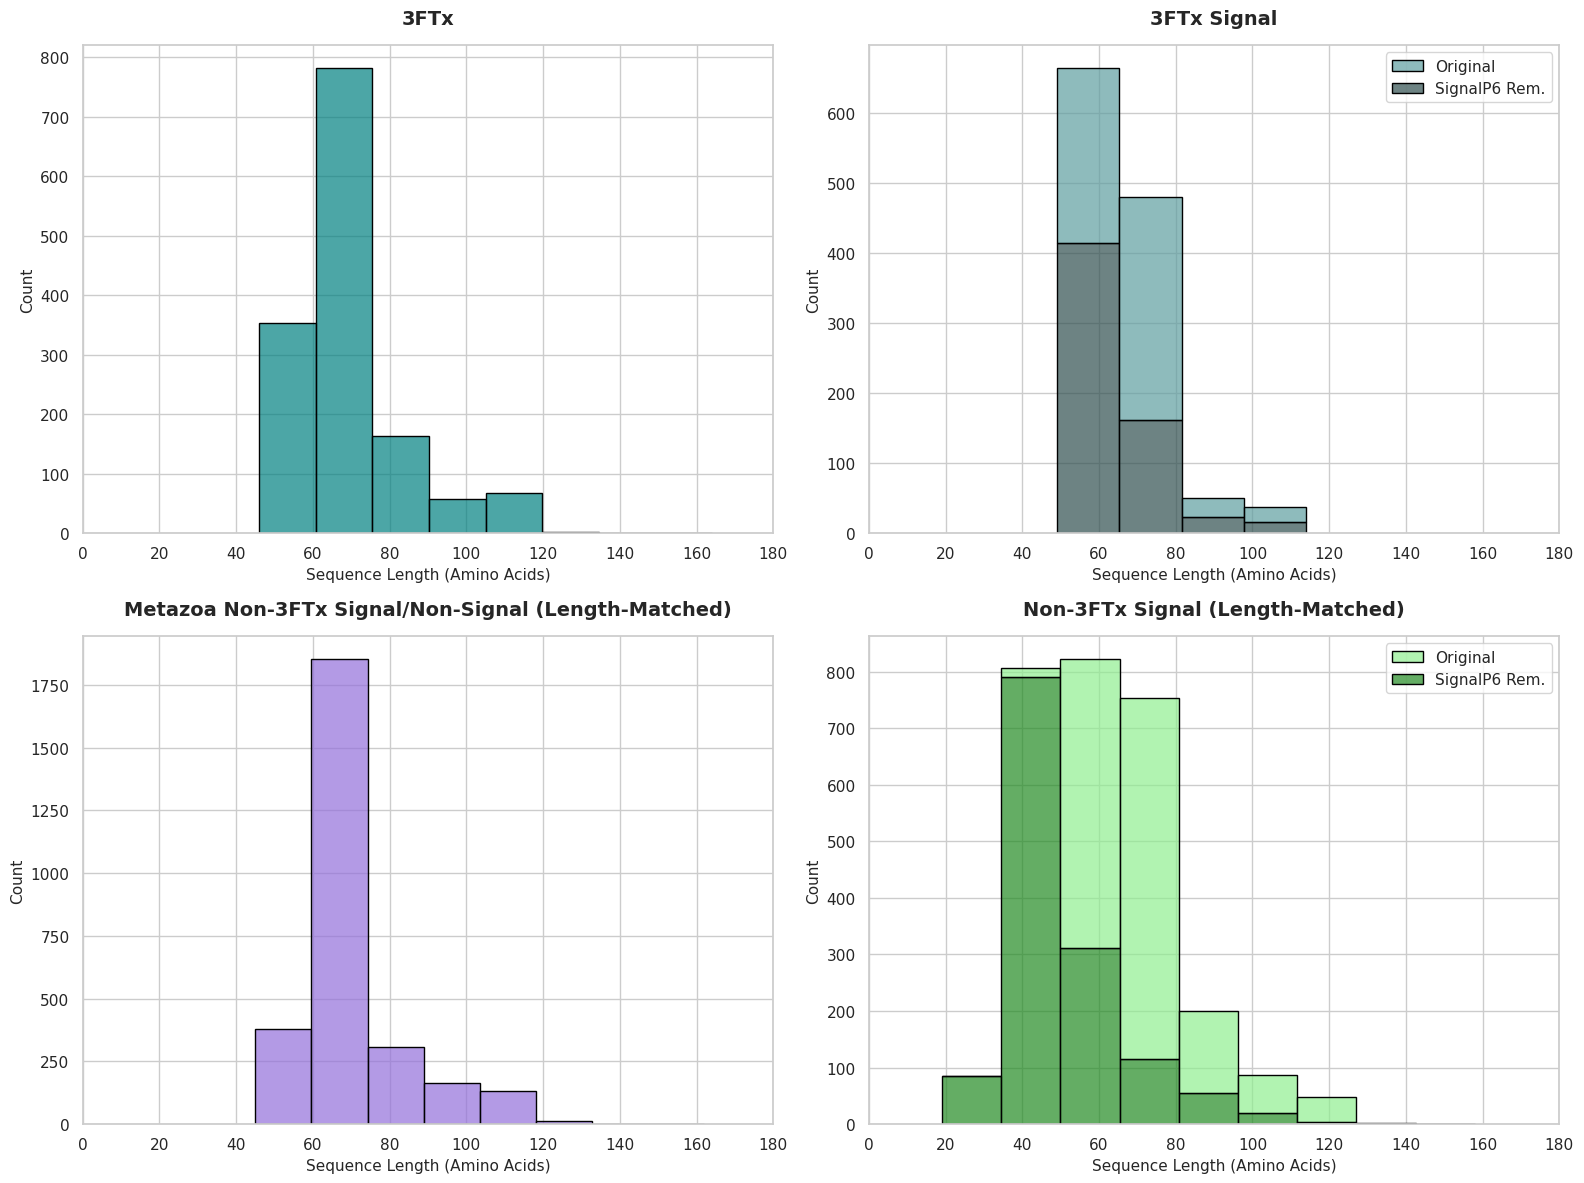

In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. Fixed Helper Function for FASTA Processing ---
def get_fasta_records(fasta_path):
    """Parses a FASTA file tracking the absolute string tail for '_2' tags."""
    if not os.path.exists(fasta_path):
        print(f"Warning: File not found at {fasta_path}. Skipping.")
        return {}
    records = {}
    current_id = None
    current_seq = []
    with open(fasta_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_id is not None:
                    records[current_id] = len("".join(current_seq))
                
                header = line[1:]
                is_removed = header.endswith("_2")
                base_id = header.split()[0]
                current_id = f"{base_id}_2" if is_removed else base_id
                
                current_seq = []
            else:
                current_seq.append(line)
        if current_id is not None:
            records[current_id] = len("".join(current_seq))
    return records

# --- 2. Load Datasets ---
# 3FTx CSV
df_3ftx = pd.read_csv("datasets/3FTx_annotation.csv")
lengths_3ftx = df_3ftx["mature_seq"].dropna().astype(str).str.len()

# 3FTx FASTA
fasta_3ftx_path = "datasets/3FTx_signal_signalp6_merged.fasta"
records_3ftx = get_fasta_records(fasta_3ftx_path)
len_3ftx_orig = []
len_3ftx_rem = []
for pid, length in records_3ftx.items():
    if pid.endswith("_2"):
        len_3ftx_rem.append(length)
    else:
        len_3ftx_orig.append(length)

# Non-3FTx FASTA
fasta_non3ftx_path = "datasets/non3FTx_signal_signalp6_merged_lengthmatched.fasta"
records_non3ftx = get_fasta_records(fasta_non3ftx_path)
len_non3ftx_orig = []
len_non3ftx_rem = []
for pid, length in records_non3ftx.items():
    if pid.endswith("_2"):
        len_non3ftx_rem.append(length)
    else:
        len_non3ftx_orig.append(length)

# Non-3FTx Metadata TSV
df_non3ftx_meta = pd.read_csv("datasets/non3FTx_5050_lengthmatched_metadata.tsv", sep='\t')
lengths_non3ftx_meta = df_non3ftx_meta["Length"].dropna()

# --- 3. Plotting Setup (2x2 Grid Layout) ---
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
TITLE_CONFIG = {"fontsize": 14, "fontweight": "bold", "pad": 15}

# Include all lengths for consistent x-axis scaling
all_lengths = (
    list(lengths_3ftx) + 
    len_3ftx_orig + len_3ftx_rem + 
    len_non3ftx_orig + len_non3ftx_rem +
    list(lengths_non3ftx_meta) 
)
max_len = max(all_lengths) if all_lengths else 120
x_limit = (max_len // 15 + 2) * 15  

# [Top-Left] CSV Annotation
sns.histplot(x=lengths_3ftx, kde=False, color="teal", binwidth=15, ax=axes[0, 0], edgecolor="black", alpha=0.7)
axes[0, 0].set_title("3FTx", **TITLE_CONFIG)
axes[0, 0].set_xlim(0, x_limit)

# [Top-Right] 3FTx FASTA
sns.histplot(
    data={"Original": len_3ftx_orig, "SignalP6 Rem.": len_3ftx_rem},
    multiple="stack", binwidth=15, kde=False,
    palette={"Original": "cadetblue", "SignalP6 Rem.": "darkslategrey"},
    edgecolor="black", alpha=0.7, ax=axes[0, 1]
)
axes[0, 1].set_title("3FTx Signal", **TITLE_CONFIG)
axes[0, 1].set_xlim(0, x_limit)

# [Bottom-Left] Non-3FTx Metadata TSV (SWAPPED TO HERE)
sns.histplot(x=lengths_non3ftx_meta, kde=False, color="mediumpurple", binwidth=15, ax=axes[1, 0], edgecolor="black", alpha=0.7)
axes[1, 0].set_title("Metazoa Non-3FTx Signal/Non-Signal (Length-Matched)", **TITLE_CONFIG)
axes[1, 0].set_xlim(0, x_limit)

# [Bottom-Right] Non-3FTx FASTA (SWAPPED TO HERE)
sns.histplot(
    data={"Original": len_non3ftx_orig, "SignalP6 Rem.": len_non3ftx_rem},
    multiple="stack", binwidth=15, kde=False,
    palette={"Original": "lightgreen", "SignalP6 Rem.": "forestgreen"},
    edgecolor="black", alpha=0.7, ax=axes[1, 1]
)
axes[1, 1].set_title("Non-3FTx Signal (Length-Matched)", **TITLE_CONFIG)
axes[1, 1].set_xlim(0, x_limit)

# Apply global formatting using flatten() to iterate through the 2D grid
for ax in axes.flatten():
    ax.set_xlabel("Sequence Length (Amino Acids)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)

plt.tight_layout()
plt.show()

Reading target dataset from datasets/uniref50_under_2k_subset.tsv...
Extracting UniProt IDs from embeddings/uniref50_background_real.h5...
Found 9,989 proteins in the background H5 file.
Mapping background IDs to lengths using datasets/uniref50_under_2k.tsv...
Successfully recovered 9,989 background sequence lengths.
Parsing FASTA dataset from datasets/uniref50_disprot.fasta...
Successfully calculated 12,212 DisProt sequence lengths.


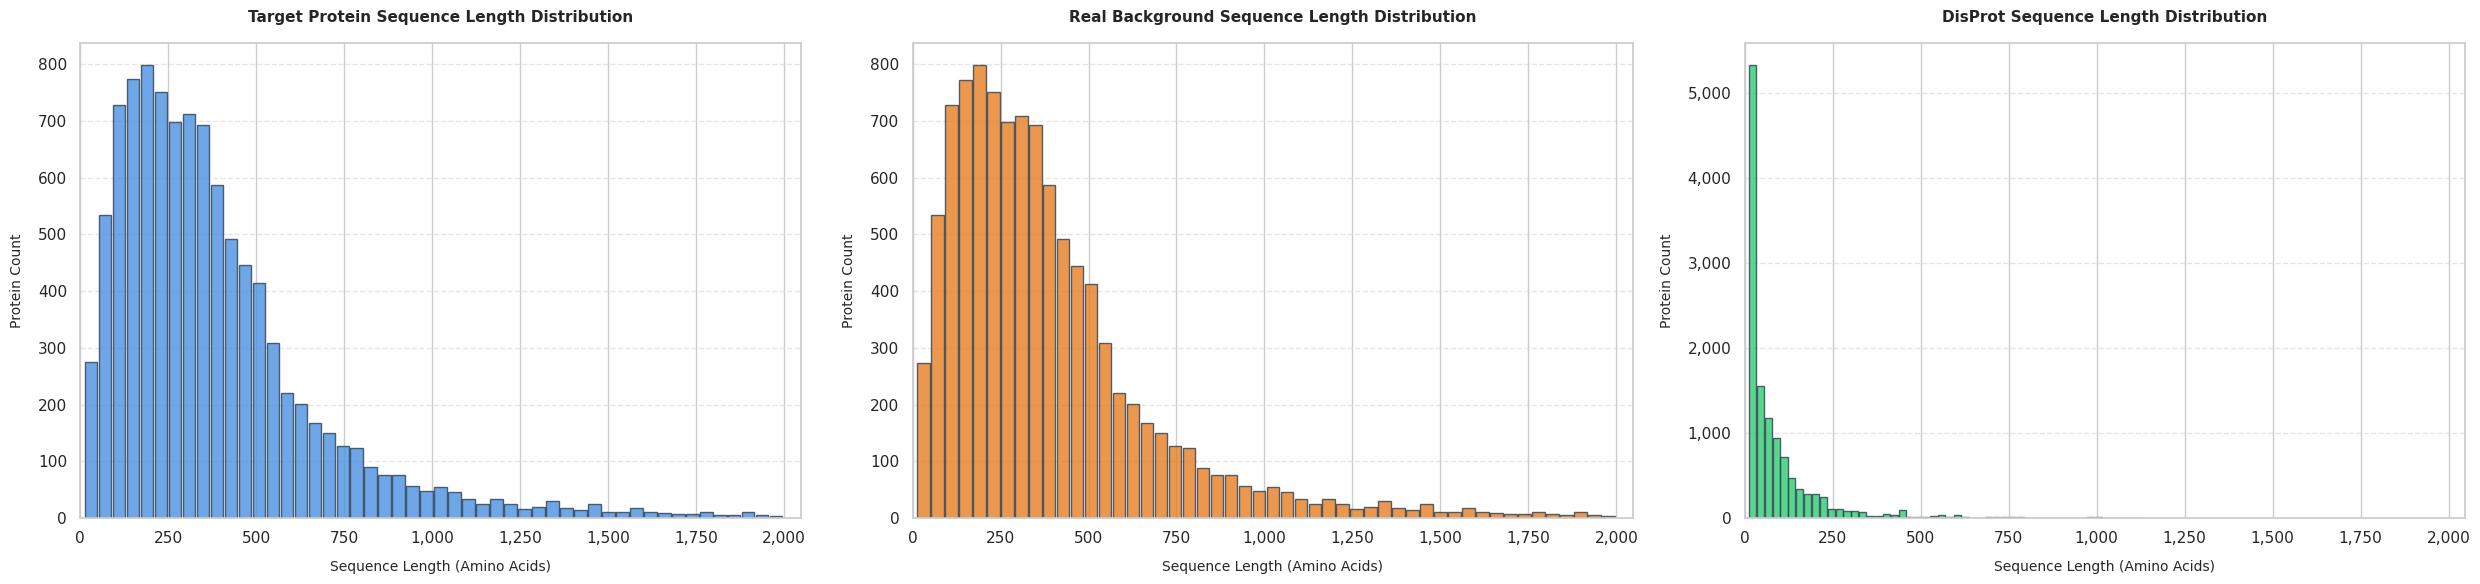

In [5]:
import os
import h5py
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Define Paths ---
TARGET_TSV = "datasets/uniref50_under_2k_subset.tsv"
FULL_TSV = "datasets/uniref50_under_2k.tsv"
BACKGROUND_H5 = "embeddings/uniref50_background_real.h5"
DISPROT_FASTA = "datasets/uniref50_disprot.fasta"  # New FASTA path

# --- 2. Load Target Dataset ---
print(f"Reading target dataset from {TARGET_TSV}...")
if not os.path.exists(TARGET_TSV):
    print(f"❌ Error: {TARGET_TSV} not found.")
    exit()

df_target = pd.read_csv(TARGET_TSV, sep="\t")

if "Length" not in df_target.columns:
    print("❌ Error: 'Length' column not found in target file.")
    exit()

# --- 3. Reverse Engineer H5 File for Background Lengths ---
print(f"Extracting UniProt IDs from {BACKGROUND_H5}...")
if not os.path.exists(BACKGROUND_H5):
    print(f"❌ Error: {BACKGROUND_H5} not found. Ensure background generation was completed.")
    exit()

with h5py.File(BACKGROUND_H5, 'r') as h5_file:
    bg_uniprot_ids = list(h5_file.keys())

print(f"Found {len(bg_uniprot_ids):,} proteins in the background H5 file.")

print(f"Mapping background IDs to lengths using {FULL_TSV}...")
if not os.path.exists(FULL_TSV):
    print(f"❌ Error: {FULL_TSV} not found. Cannot map lengths without full metadata.")
    exit()

df_full = pd.read_csv(FULL_TSV, sep="\t")
df_bg_matched = df_full[df_full['From'].isin(bg_uniprot_ids)]
background_lengths = df_bg_matched['Length']

print(f"Successfully recovered {len(background_lengths):,} background sequence lengths.")

# --- 4. Parse FASTA File for DisProt Lengths ---
print(f"Parsing FASTA dataset from {DISPROT_FASTA}...")
if not os.path.exists(DISPROT_FASTA):
    print(f"❌ Error: {DISPROT_FASTA} not found.")
    exit()

disprot_lengths = []
current_length = 0

with open(DISPROT_FASTA, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_length > 0:
                disprot_lengths.append(current_length)
                current_length = 0
        else:
            current_length += len(line)
    # Catch the final sequence in the file
    if current_length > 0:
        disprot_lengths.append(current_length)

print(f"Successfully calculated {len(disprot_lengths):,} DisProt sequence lengths.")

# --- 5. Setup the Plot Canvas (1x3 Grid Layout) ---
# Expanded figsize width to 25 to cleanly fit three plots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

comma_formatter = plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))

# --- Plot 1 (Left): Target Subset Distribution ---
axes[0].hist(
    df_target["Length"], 
    bins=50, 
    color="#4A90E2", 
    edgecolor="#2C3E50", 
    alpha=0.8, 
    rwidth=0.9
)
axes[0].set_title("Target Protein Sequence Length Distribution", fontsize=11, fontweight="bold", pad=15)
axes[0].set_xlabel("Sequence Length (Amino Acids)", fontsize=10, labelpad=10)
axes[0].set_ylabel("Protein Count", fontsize=10, labelpad=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].get_yaxis().set_major_formatter(comma_formatter)
axes[0].get_xaxis().set_major_formatter(comma_formatter)

# --- Plot 2 (Middle): Recovered Background Distribution ---
axes[1].hist(
    background_lengths, 
    bins=50, 
    color="#E67E22", 
    edgecolor="#2C3E50", 
    alpha=0.8, 
    rwidth=0.9
)
axes[1].set_title("Real Background Sequence Length Distribution", fontsize=11, fontweight="bold", pad=15)
axes[1].set_xlabel("Sequence Length (Amino Acids)", fontsize=10, labelpad=10)
axes[1].set_ylabel("Protein Count", fontsize=10, labelpad=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].get_yaxis().set_major_formatter(comma_formatter)
axes[1].get_xaxis().set_major_formatter(comma_formatter)

# --- Plot 3 (Right): DisProt Distribution ---
axes[2].hist(
    disprot_lengths, 
    bins=50, 
    color="#2ECC71",  # Distinct color (Emerald Green)
    edgecolor="#2C3E50", 
    alpha=0.8, 
    rwidth=0.9
)
axes[2].set_title("DisProt Sequence Length Distribution", fontsize=11, fontweight="bold", pad=15)
axes[2].set_xlabel("Sequence Length (Amino Acids)", fontsize=10, labelpad=10)
axes[2].set_ylabel("Protein Count", fontsize=10, labelpad=10)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
axes[2].get_yaxis().set_major_formatter(comma_formatter)
axes[2].get_xaxis().set_major_formatter(comma_formatter)

# Ensure all three plots use identical x-axis scales for fair visual comparison
max_x_limit = max(df_target["Length"].max(), background_lengths.max(), max(disprot_lengths))
for ax in axes:
    ax.set_xlim(0, max_x_limit + 50)

# Adjust margins automatically to prevent text truncation
plt.tight_layout()

# Save or display the final comparison
plt.show()
plt.close()